# 04_06 Classification - DecisionTreeClassifier

Train and evaluate Decision Tree Classifier on `features/classification_fe`.

[COMMAND_SO]
Command 1

[COMMAND_MUC_DICH]
- Muc tieu nghiep vu: Train DecisionTreeClassifier va hien thi ket qua danh gia ro rang tren notebook.
- Muc tieu ky thuat: Su dung split train/val/test 70/15/15 va ve confusion matrix + bang metric.

In [1]:
from pathlib import Path
import json
from pyspark.sql import SparkSession
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

spark = (SparkSession.builder.appName('04_06_dt').master('local[2]').config('spark.sql.shuffle.partitions','16').getOrCreate())
spark.sparkContext.setLogLevel('WARN')
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
FEATURE_DIR = PROJECT_ROOT / 'data' / 'processed' / 'features'
MODEL_DIR = PROJECT_ROOT / 'models' / 'classification' / 'decision_tree_classifier'
METRIC_DIR = PROJECT_ROOT / 'reports' / 'model_metrics'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)
train_df = spark.read.parquet(str(FEATURE_DIR / 'classification_train')).select('order_id','label','features').dropna()
val_df = spark.read.parquet(str(FEATURE_DIR / 'classification_val')).select('order_id','label','features').dropna()
test_df = spark.read.parquet(str(FEATURE_DIR / 'classification_test')).select('order_id','label','features').dropna()

{'model_family': 'classification', 'model_name': 'DecisionTreeClassifier', 'val_f1': 0.7311007546131713, 'val_accuracy': 0.806248323947439, 'val_precision': 0.7427564709126219, 'val_recall': 0.806248323947439, 'f1': 0.7568585973867886, 'accuracy': 0.8239474389916868, 'precision': 0.7822818170046967, 'recall': 0.8239474389916868, 'test_f1': 0.7568585973867886, 'test_accuracy': 0.8239474389916868, 'test_precision': 0.7822818170046967, 'test_recall': 0.8239474389916868, 'train_rows': 69609, 'val_rows': 14916, 'test_rows': 14916}


,model_family,model_name,val_f1,val_accuracy,val_precision,val_recall,f1,accuracy,precision,recall,test_f1,test_accuracy,test_precision,test_recall,train_rows,val_rows,test_rows
0,classification,DecisionTreeClassifier,0.731101,0.806248,0.742756,0.806248,0.756859,0.823947,0.782282,0.823947,0.756859,0.823947,0.782282,0.823947,69609,14916,14916


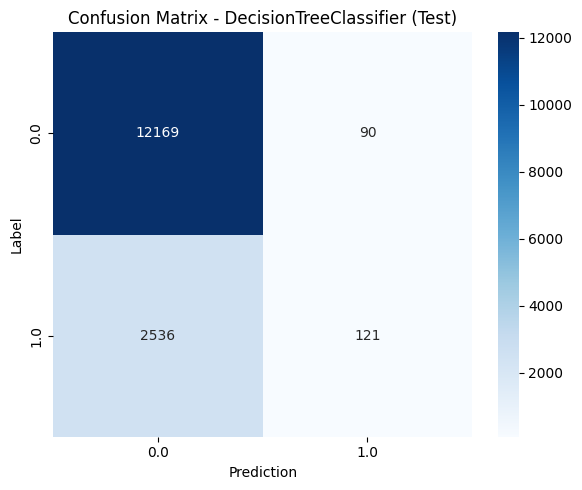

567

In [2]:
model = DecisionTreeClassifier(featuresCol='features', labelCol='label', maxDepth=12, maxBins=32, seed=42)
dt_model = model.fit(train_df)
pred_val = dt_model.transform(val_df)
pred_test = dt_model.transform(test_df)

# Evaluators
evaluator_f1 = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1')
evaluator_acc = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')
evaluator_precision = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedPrecision')
evaluator_recall = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedRecall')

# Calculate metrics
val_f1 = evaluator_f1.evaluate(pred_val)
val_acc = evaluator_acc.evaluate(pred_val)
val_precision = evaluator_precision.evaluate(pred_val)
val_recall = evaluator_recall.evaluate(pred_val)
test_f1 = evaluator_f1.evaluate(pred_test)
test_acc = evaluator_acc.evaluate(pred_test)
test_precision = evaluator_precision.evaluate(pred_test)
test_recall = evaluator_recall.evaluate(pred_test)

metrics = {
    'model_family': 'classification',
    'model_name': 'DecisionTreeClassifier',
    'val_f1': float(val_f1),
    'val_accuracy': float(val_acc),
    'val_precision': float(val_precision),
    'val_recall': float(val_recall),
    'f1': float(test_f1),
    'accuracy': float(test_acc),
    'precision': float(test_precision),
    'recall': float(test_recall),
    'test_f1': float(test_f1),
    'test_accuracy': float(test_acc),
    'test_precision': float(test_precision),
    'test_recall': float(test_recall),
    'train_rows': train_df.count(),
    'val_rows': val_df.count(),
    'test_rows': test_df.count()
}
print(metrics)
display(pd.DataFrame([metrics]))
cm_pdf = pred_test.groupBy('label', 'prediction').count().toPandas()
if not cm_pdf.empty:
    cm_table = cm_pdf.pivot(index='label', columns='prediction', values='count').fillna(0).sort_index().sort_index(axis=1)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_table, annot=True, fmt='.0f', cmap='Blues')
    plt.title('Confusion Matrix - DecisionTreeClassifier (Test)')
    plt.xlabel('Prediction')
    plt.ylabel('Label')
    plt.tight_layout()
    plt.show()
dt_model.write().overwrite().save(str(MODEL_DIR))
(METRIC_DIR / 'classification_decision_tree.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')